<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/CO2alkonolamines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )

# Solubility of CO₂ in MDEA

This notebook preserves the original CO₂–water–MDEA examples and develops them into a
reproducible engineering workflow for reactive equilibrium, aqueous speciation, model
comparison, solvent-rate screening, and a NeqSim gas–liquid contact process.

## Use of the Electrolyte CPA equation of state

The first preserved example uses `Electrolyte-CPA-EoS`, initializes chemical reactions,
applies mixing rule 10, and calculates the pressure where an infinitesimal second phase
appears. See the model discussion in [Solbraa (2002)](
https://ntnuopen.ntnu.no/ntnu-xmlui/handle/11250/231326).

NeqSim 3.16.0 may classify the incipient CO₂-rich phase as `OIL` rather than `GAS` for this
high bubble pressure. The repaired calculation therefore identifies the phase with the
smallest phase fraction instead of assuming that a phase named `gas` exists.

In [2]:
from neqsim.thermo import bubp, fluid

feedgas = fluid("Electrolyte-CPA-EoS")
feedgas.addComponent("CO2", 0.875, "kg/sec")
feedgas.addComponent("water", 10.0, "kg/sec")
feedgas.addComponent("MDEA", 2.0, "kg/sec")
feedgas.chemicalReactionInit()
feedgas.setMixingRule(10)
feedgas.setTemperature(45.0, "C")
feedgas.setPressure(0.4, "bara")
feedgas.init(0)

loading = (
    feedgas.getComponent("CO2").getz()
    / feedgas.getComponent("MDEA").getz()
)
original_cpa_bubble_pressure_bara = bubp(feedgas)
incipient_phase = min(
    [feedgas.getPhase(index) for index in range(feedgas.getNumberOfPhases())],
    key=lambda phase: phase.getBeta(),
)
incipient_co2_pressure_mpa = (
    incipient_phase.getComponent("CO2").getx()
    * original_cpa_bubble_pressure_bara
    * 0.1
)

print(f"Overall loading: {loading:.6f} mol CO2/mol MDEA")
print(
    "Bubble pressure: "
    f"{original_cpa_bubble_pressure_bara * 0.1:.6f} MPa"
)
print(
    "Incipient phase: "
    f"{incipient_phase.getType()}, beta={incipient_phase.getBeta():.3e}"
)
print(
    "Incipient-phase CO2 pressure contribution: "
    f"{incipient_co2_pressure_mpa:.6f} MPa"
)

Overall loading: 1.184592 mol CO2/mol MDEA
Bubble pressure: 36.291804 MPa
Incipient phase: OIL, beta=1.000e-10
Incipient-phase CO2 pressure contribution: 36.068770 MPa


## Thermodynamics of CO₂ and alkanolamines

The second preserved example calculates reactive phase equilibrium for sour natural gas
contacted with aqueous MDEA. The result distinguishes molecular CO₂ from bicarbonate and
carbonate, and neutral MDEA from protonated MDEA. This is essential: total liquid loading
cannot be inferred from molecular CO₂ alone.

In [3]:
from neqsim.thermo import TPflash

feedgas = fluid("Electrolyte-CPA-EoS")
feedgas.addComponent("CO2", 2.12, "kg/sec")
feedgas.addComponent("methane", 90.0, "kg/sec")
feedgas.addComponent("ethane", 2.0, "kg/sec")
feedgas.addComponent("water", 10.0, "kg/sec")
feedgas.addComponent("MDEA", 1.0, "kg/sec")
feedgas.chemicalReactionInit()
feedgas.setMixingRule(10)
feedgas.setTemperature(45.0, "C")
feedgas.setPressure(55.0, "bara")

TPflash(feedgas)

aqueous_phase = feedgas.getPhase("aqueous")
aqueous_carbon = (
    aqueous_phase.getComponent("CO2").getx()
    + aqueous_phase.getComponent("HCO3-").getx()
    + aqueous_phase.getComponent("CO3--").getx()
)
aqueous_amine = (
    aqueous_phase.getComponent("MDEA").getx()
    + aqueous_phase.getComponent("MDEA+").getx()
)
high_pressure_loading = aqueous_carbon / aqueous_amine
high_pressure_pco2_mpa = (
    feedgas.getPhase("gas").getComponent("CO2").getx()
    * feedgas.getPressure()
    * 0.1
)

print(
    f"Liquid loading: {high_pressure_loading:.6f} mol CO2/mol MDEA"
)
print(f"Gas-phase CO2 partial pressure: {high_pressure_pco2_mpa:.6f} MPa")

Liquid loading: 0.016196 mol CO2/mol MDEA
Gas-phase CO2 partial pressure: 0.046134 MPa


## Use of the Electrolyte ScRK model

The third preserved example repeats the low-pressure bubble-point calculation with
`Electrolyte-ScRK-EoS` and mixing rule 4. Comparing this result with Electrolyte-CPA
demonstrates model-form sensitivity; it is not a claim that either model is universally
more accurate. Project work should validate the selected model against representative
VLE, heat-of-absorption, density, and speciation data.

In [4]:
feedgas = fluid("Electrolyte-ScRK-EoS")
feedgas.addComponent("CO2", 0.405, "kg/sec")
feedgas.addComponent("water", 10.0, "kg/sec")
feedgas.addComponent("MDEA", 2.0, "kg/sec")
feedgas.chemicalReactionInit()
feedgas.setMixingRule(4)
feedgas.setTemperature(40.0, "C")
feedgas.setPressure(0.4, "bara")
feedgas.init(0)

loading = (
    feedgas.getComponent("CO2").getz()
    / feedgas.getComponent("MDEA").getz()
)
original_scrk_bubble_pressure_bara = bubp(feedgas)
incipient_phase = min(
    [feedgas.getPhase(index) for index in range(feedgas.getNumberOfPhases())],
    key=lambda phase: phase.getBeta(),
)
scrk_co2_pressure_mpa = (
    incipient_phase.getComponent("CO2").getx()
    * original_scrk_bubble_pressure_bara
    * 0.1
)

print(f"Overall loading: {loading:.6f} mol CO2/mol MDEA")
print(
    "Bubble pressure: "
    f"{original_scrk_bubble_pressure_bara * 0.1:.6f} MPa"
)
print(
    "Incipient phase: "
    f"{incipient_phase.getType()}, beta={incipient_phase.getBeta():.3e}"
)
print(
    "Incipient-phase CO2 pressure contribution: "
    f"{scrk_co2_pressure_mpa:.6f} MPa"
)

Overall loading: 0.548297 mol CO2/mol MDEA
Bubble pressure: 0.471566 MPa
Incipient phase: GAS, beta=1.000e-10
Incipient-phase CO2 pressure contribution: 0.464200 MPa


## Audience, prerequisites, and learning objectives

**Audience.** Process, gas-treating, and thermodynamics engineers who know basic phase
equilibrium and Python.

**Prerequisites.** Familiarity with mole fraction, partial pressure, material balance, and
equilibrium-stage approximations. A clean Google Colab runtime is sufficient.

After completing the notebook, you should be able to:

1. construct reactive electrolyte fluids with NeqSim;
2. distinguish overall loading, aqueous loading, and gas-phase CO₂ partial pressure;
3. compare Electrolyte-CPA and Electrolyte-ScRK without hiding model uncertainty;
4. interpret MDEA speciation and loading/temperature sensitivities;
5. connect NeqSim streams, a mixer, and a separator into an equilibrium-contact process;
6. check mass and CO₂ balances before using a result for design screening.

In [5]:
from importlib.metadata import version
import platform
import subprocess

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim.process import (
    clearProcess,
    mixer,
    runProcess,
    separator,
    stream,
)

neqsim_version = version("neqsim")
python_version = platform.python_version()
java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim: {neqsim_version}")
print(f"Python: {python_version}")
print(f"Java: {java_version}")

NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## Reactive-equilibrium basis

MDEA is a tertiary amine. In this simplified equilibrium description, CO₂ hydration and
acid-base reactions distribute inorganic carbon among molecular CO₂, bicarbonate, and
carbonate, while MDEA is distributed between neutral and protonated forms.

$$
\mathrm{CO_2 + H_2O \rightleftharpoons HCO_3^- + H^+}
$$

$$
\mathrm{MDEA + H^+ \rightleftharpoons MDEAH^+}
$$

The aqueous loading used here is

$$
\alpha =
\frac{x_{\mathrm{CO_2}} + x_{\mathrm{HCO_3^-}} + x_{\mathrm{CO_3^{2-}}}}
{x_{\mathrm{MDEA}} + x_{\mathrm{MDEAH^+}}}
$$

where $\alpha$ is in mol CO₂/mol MDEA and every $x_i$ is an aqueous-phase mole
fraction. Gas-phase partial pressure follows

$$
p_{\mathrm{CO_2}} = y_{\mathrm{CO_2}} P
$$

where $p_{\mathrm{CO_2}}$ and total pressure $P$ use the same pressure unit.

In [6]:
def phase_inventory(system):
    records = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        records.append(
            {
                "phase_index": phase_index,
                "phase_type": str(phase.getType()),
                "phase_fraction": float(phase.getBeta()),
            }
        )
    return pd.DataFrame(records)


def calculate_aqueous_loading(system):
    aqueous = system.getPhase("aqueous")
    carbon_mole_fraction = (
        aqueous.getComponent("CO2").getx()
        + aqueous.getComponent("HCO3-").getx()
        + aqueous.getComponent("CO3--").getx()
    )
    amine_mole_fraction = (
        aqueous.getComponent("MDEA").getx()
        + aqueous.getComponent("MDEA+").getx()
    )
    return float(carbon_mole_fraction / amine_mole_fraction)


def gas_co2_partial_pressure_mpa(system):
    gas = system.getPhase("gas")
    return float(gas.getComponent("CO2").getx() * system.getPressure() * 0.1)


phase_inventory(feedgas)

,phase_index,phase_type,phase_fraction
0,0,GAS,1.000000e-10
1,1,AQUEOUS,1.000000e+00


The NeqSim workflow has four layers:

- the **fluid** stores components, phases, reactions, model, state, and mixing rule;
- a **thermodynamic operation** such as `TPflash` or `bubp` solves equilibrium;
- **streams** carry thermodynamic systems through a process model;
- **unit operations** mix and separate streams, while `runProcess()` orders and solves the
  connected equipment.

The diagram below previews the final application. It is an equilibrium-stage screen, not a
rate-based absorber model: it assumes perfect mixing, equilibrium at the specified outlet
temperature and pressure, no heat loss, no pressure drop, and no kinetic or tray/packing
efficiency limitation.

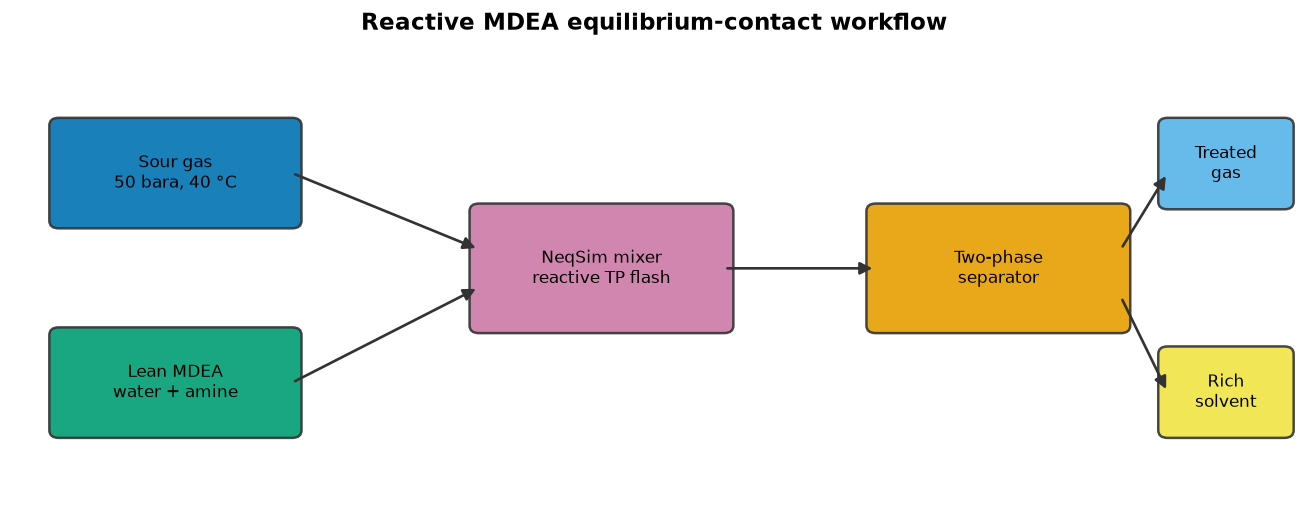

In [7]:
figure, axis = plt.subplots(figsize=(11, 4.5))
axis.set_xlim(0, 11)
axis.set_ylim(0, 5)
axis.axis("off")

boxes = [
    (0.4, 3.1, 2.0, 1.0, "Sour gas\n50 bara, 40 °C", "#0072B2"),
    (0.4, 0.9, 2.0, 1.0, "Lean MDEA\nwater + amine", "#009E73"),
    (4.0, 2.0, 2.1, 1.2, "NeqSim mixer\nreactive TP flash", "#CC79A7"),
    (7.4, 2.0, 2.1, 1.2, "Two-phase\nseparator", "#E69F00"),
    (9.9, 3.3, 1.0, 0.8, "Treated\ngas", "#56B4E9"),
    (9.9, 0.9, 1.0, 0.8, "Rich\nsolvent", "#F0E442"),
]

for x_position, y_position, width, height, label, color in boxes:
    patch = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.5,
        alpha=0.9,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

arrows = [
    ((2.4, 3.6), (4.0, 2.8)),
    ((2.4, 1.4), (4.0, 2.4)),
    ((6.1, 2.6), (7.4, 2.6)),
    ((9.5, 2.8), (9.9, 3.6)),
    ((9.5, 2.3), (9.9, 1.3)),
]
for start, end in arrows:
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.6,
            color="#333333",
        )
    )

axis.set_title(
    "Reactive MDEA equilibrium-contact workflow",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()

## Inspect aqueous speciation

The preserved high-pressure case provides a compact speciation example. Mole fractions
are reported directly by the NeqSim aqueous phase. Ionic species are model-dependent
equilibrium results; they should not be treated as analytical measurements without
validation of the electrolyte model and interaction parameters.

In [8]:
speciation_system = fluid("Electrolyte-CPA-EoS")
speciation_system.addComponent("CO2", 2.12, "kg/sec")
speciation_system.addComponent("methane", 90.0, "kg/sec")
speciation_system.addComponent("ethane", 2.0, "kg/sec")
speciation_system.addComponent("water", 10.0, "kg/sec")
speciation_system.addComponent("MDEA", 1.0, "kg/sec")
speciation_system.chemicalReactionInit()
speciation_system.setMixingRule(10)
speciation_system.setTemperature(45.0, "C")
speciation_system.setPressure(55.0, "bara")
TPflash(speciation_system)

aqueous = speciation_system.getPhase("aqueous")
species_names = ["CO2", "HCO3-", "CO3--", "MDEA", "MDEA+", "water"]
speciation_table = pd.DataFrame(
    {
        "species": species_names,
        "aqueous_mole_fraction": [
            float(aqueous.getComponent(name).getx())
            for name in species_names
        ],
    }
)
speciation_table

,species,aqueous_mole_fraction
0,CO2,6.516562e-06
1,HCO3-,2.394211e-04
2,CO3--,2.155302e-11
3,MDEA,1.494587e-02
4,MDEA+,2.392739e-04
5,water,9.834677e-01


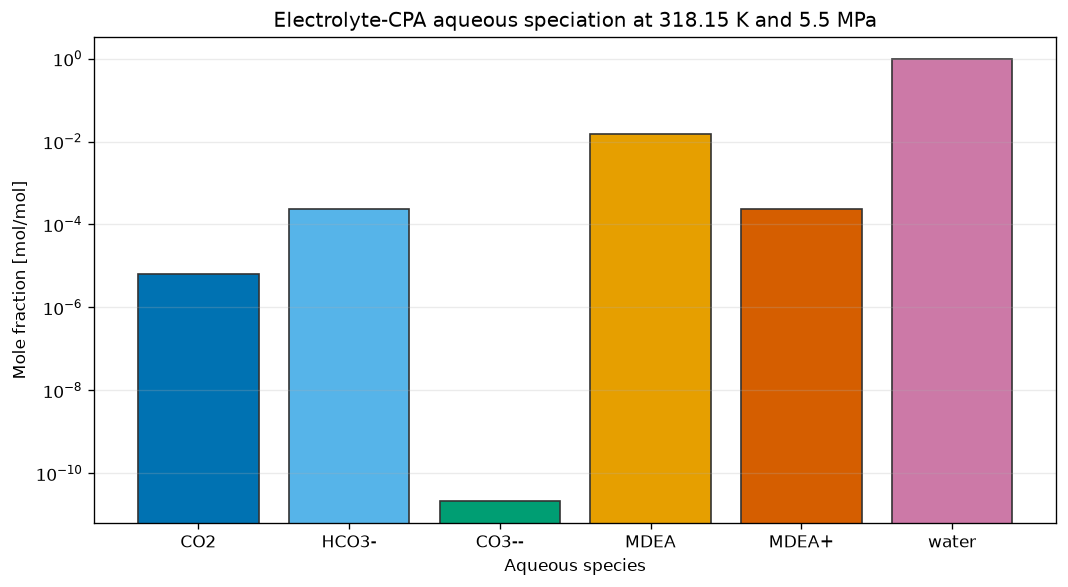

In [9]:
figure, axis = plt.subplots(figsize=(9, 5))
colors = ["#0072B2", "#56B4E9", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]
axis.bar(
    speciation_table["species"],
    speciation_table["aqueous_mole_fraction"],
    color=colors,
    edgecolor="#333333",
)
axis.set_yscale("log")
axis.set_xlabel("Aqueous species")
axis.set_ylabel("Mole fraction [mol/mol]")
axis.set_title("Electrolyte-CPA aqueous speciation at 318.15 K and 5.5 MPa")
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()

Water dominates the aqueous phase, so a logarithmic scale is needed to show carbon and
amine species together. The engineering quantity used for solvent loading is the ratio of
the summed carbon-bearing species to the summed neutral and protonated MDEA species.

## Build equilibrium loading curves

For each model, temperature, and CO₂/MDEA feed ratio, NeqSim first initializes chemical
reactions and then calculates the pressure at which an infinitesimal second phase appears.
The resulting incipient-phase CO₂ pressure contribution is used as a consistent screening
coordinate.

This is a synthetic, reproducible model-comparison grid. It is not an experimental
benchmark, and the high-pressure endpoint of the CPA curve should be checked carefully
because its incipient phase can be liquid-like.

In [10]:
def calculate_loading_point(
    model_name,
    mixing_rule,
    temperature_k,
    co2_mass_rate,
    water_mass_rate=10.0,
    mdea_mass_rate=2.0,
):
    system = fluid(model_name)
    system.addComponent("CO2", co2_mass_rate, "kg/sec")
    system.addComponent("water", water_mass_rate, "kg/sec")
    system.addComponent("MDEA", mdea_mass_rate, "kg/sec")
    system.chemicalReactionInit()
    system.setMixingRule(mixing_rule)
    system.setTemperature(temperature_k, "K")
    system.setPressure(0.4, "bara")
    system.init(0)

    overall_loading = (
        system.getComponent("CO2").getz()
        / system.getComponent("MDEA").getz()
    )
    bubble_pressure_bara = bubp(system)
    incipient = min(
        [system.getPhase(index) for index in range(system.getNumberOfPhases())],
        key=lambda phase: phase.getBeta(),
    )
    co2_pressure_mpa = (
        incipient.getComponent("CO2").getx()
        * bubble_pressure_bara
        * 0.1
    )
    return {
        "model": model_name,
        "temperature_k": temperature_k,
        "loading_mol_per_mol": float(overall_loading),
        "bubble_pressure_mpa": float(bubble_pressure_bara * 0.1),
        "co2_pressure_mpa": float(co2_pressure_mpa),
        "incipient_phase": str(incipient.getType()),
    }


co2_mass_rates = [0.15, 0.30, 0.50, 0.70]
cpa_records = []
for temperature_k in [313.15, 333.15]:
    for co2_mass_rate in co2_mass_rates:
        cpa_records.append(
            calculate_loading_point(
                "Electrolyte-CPA-EoS",
                10,
                temperature_k,
                co2_mass_rate,
            )
        )

cpa_isotherms = pd.DataFrame(cpa_records)
cpa_isotherms

,model,temperature_k,loading_mol_per_mol,bubble_pressure_mpa,co2_pressure_mpa,incipient_phase
0,Electrolyte-CPA-EoS,313.15,0.203073,0.403605,0.396376,GAS
1,Electrolyte-CPA-EoS,313.15,0.406146,1.143308,1.135686,GAS
2,Electrolyte-CPA-EoS,313.15,0.676910,3.188136,3.179110,GAS
3,Electrolyte-CPA-EoS,313.15,0.947674,8.565364,8.544956,GAS
4,Electrolyte-CPA-EoS,333.15,0.203073,0.677915,0.658195,GAS
5,Electrolyte-CPA-EoS,333.15,0.406146,2.165311,2.143742,GAS
6,Electrolyte-CPA-EoS,333.15,0.676910,6.287333,6.258145,GAS
7,Electrolyte-CPA-EoS,333.15,0.947674,36.470134,36.166728,GAS


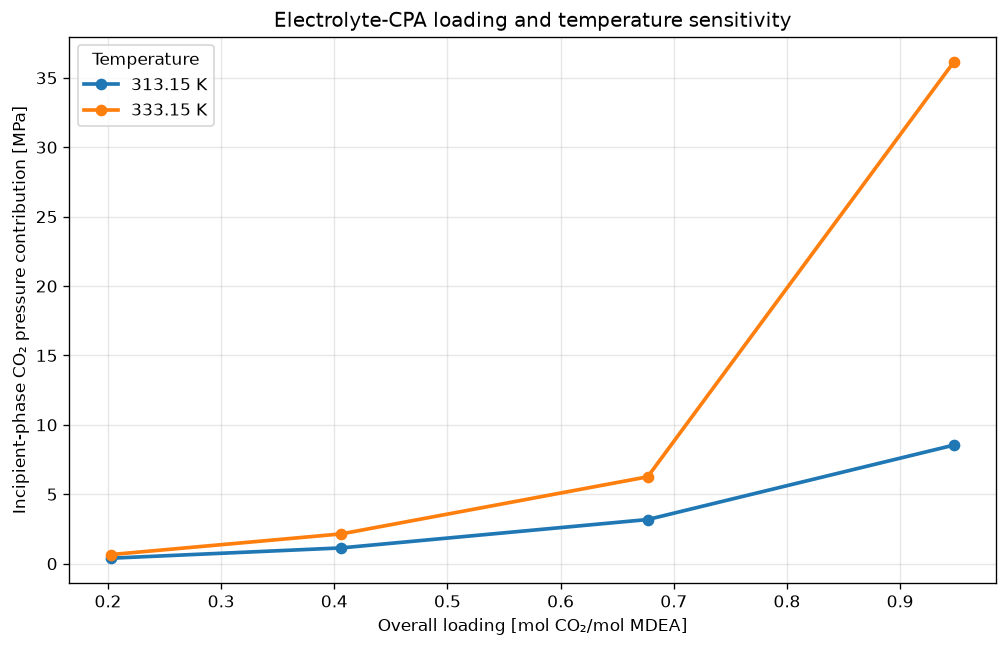

In [11]:
figure, axis = plt.subplots(figsize=(8.5, 5.5))
for temperature_k, group in cpa_isotherms.groupby("temperature_k"):
    ordered = group.sort_values("loading_mol_per_mol")
    axis.plot(
        ordered["loading_mol_per_mol"],
        ordered["co2_pressure_mpa"],
        marker="o",
        linewidth=2.2,
        label=f"{temperature_k:.2f} K",
    )

axis.set_xlabel("Overall loading [mol CO₂/mol MDEA]")
axis.set_ylabel("Incipient-phase CO₂ pressure contribution [MPa]")
axis.set_title("Electrolyte-CPA loading and temperature sensitivity")
axis.grid(alpha=0.3)
axis.legend(title="Temperature")
plt.tight_layout()

The curves show the model-predicted pressure required to support increasing overall
loading. Temperature changes both physical solubility and chemical equilibrium. A
rate-based absorber design also needs reaction and mass-transfer kinetics, heat effects,
hydraulics, and stage or packing efficiency; those effects are outside this equilibrium
screen.

## Compare electrolyte model forms

The following comparison holds feed rates and temperature fixed. Only the electrolyte
model and its prescribed mixing rule change. Large differences are a warning to validate
against project-specific data rather than average the curves.

In [12]:
comparison_records = []
comparison_co2_mass_rates = [0.05, 0.10, 0.15, 0.20]
for model_name, mixing_rule in [
    ("Electrolyte-CPA-EoS", 10),
    ("Electrolyte-ScRK-EoS", 4),
]:
    for co2_mass_rate in comparison_co2_mass_rates:
        comparison_records.append(
            calculate_loading_point(
                model_name,
                mixing_rule,
                313.15,
                co2_mass_rate,
            )
        )

model_comparison = pd.DataFrame(comparison_records)
model_comparison

,model,temperature_k,loading_mol_per_mol,bubble_pressure_mpa,co2_pressure_mpa,incipient_phase
0,Electrolyte-CPA-EoS,313.15,0.067691,0.067757,0.060686,GAS
1,Electrolyte-CPA-EoS,313.15,0.135382,0.222738,0.215596,GAS
2,Electrolyte-CPA-EoS,313.15,0.203073,0.403605,0.396376,GAS
3,Electrolyte-CPA-EoS,313.15,0.270764,0.671870,0.664502,GAS
4,Electrolyte-ScRK-EoS,313.15,0.067691,0.019177,0.011998,GAS
5,Electrolyte-ScRK-EoS,313.15,0.135382,0.047358,0.040173,GAS
6,Electrolyte-ScRK-EoS,313.15,0.203073,0.087677,0.080480,GAS
7,Electrolyte-ScRK-EoS,313.15,0.270764,0.138838,0.131623,GAS


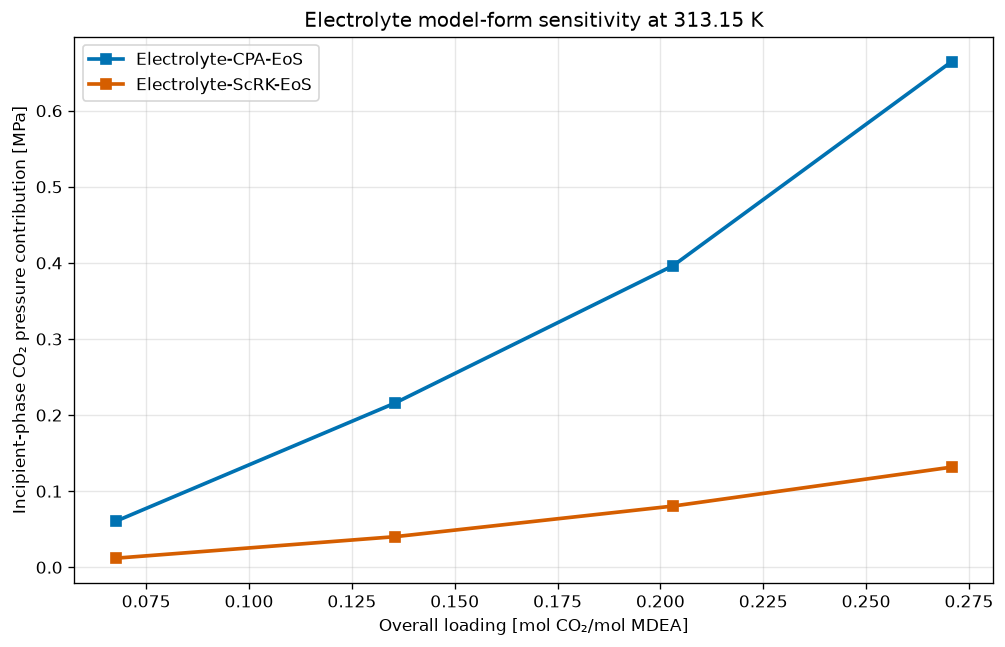

In [13]:
figure, axis = plt.subplots(figsize=(8.5, 5.5))
model_colors = {
    "Electrolyte-CPA-EoS": "#0072B2",
    "Electrolyte-ScRK-EoS": "#D55E00",
}
for model_name, group in model_comparison.groupby("model"):
    ordered = group.sort_values("loading_mol_per_mol")
    axis.plot(
        ordered["loading_mol_per_mol"],
        ordered["co2_pressure_mpa"],
        marker="s",
        linewidth=2.2,
        color=model_colors[model_name],
        label=model_name,
    )

axis.set_xlabel("Overall loading [mol CO₂/mol MDEA]")
axis.set_ylabel("Incipient-phase CO₂ pressure contribution [MPa]")
axis.set_title("Electrolyte model-form sensitivity at 313.15 K")
axis.grid(alpha=0.3)
axis.legend()
plt.tight_layout()

## Final application: an equilibrium MDEA contact stage

The final workflow uses NeqSim process objects rather than isolated flashes:

1. create a sour-gas stream and a lean-solvent stream with the same electrolyte model;
2. combine them in a native `Mixer`;
3. let the mixed outlet perform its reactive equilibrium calculation;
4. split the equilibrium phases in a native two-phase `Separator`;
5. retrieve treated-gas and rich-solvent streams;
6. vary MDEA circulation and check total and CO₂ balances.

A trace rate of $10^{-6}$ kg/s is added only to align component inventories between the
two independently constructed streams. It is less than one part per million of the main
flows and is included explicitly in every balance.

In [14]:
TRACE_MASS_RATE_KG_PER_S = 1.0e-6


def make_contact_fluid(component_mass_rates, temperature_k, pressure_bara):
    system = fluid("Electrolyte-CPA-EoS")
    for component_name, mass_rate in component_mass_rates.items():
        system.addComponent(component_name, mass_rate, "kg/sec")
    system.chemicalReactionInit()
    system.setMixingRule(10)
    system.setTemperature(temperature_k, "K")
    system.setPressure(pressure_bara, "bara")
    return system


def run_equilibrium_contact(mdea_mass_rate):
    temperature_k = 313.15
    pressure_bara = 50.0
    gas_rates = {
        "methane": 18.0,
        "CO2": 1.0,
        "water": 0.01,
        "MDEA": TRACE_MASS_RATE_KG_PER_S,
    }
    solvent_rates = {
        "methane": TRACE_MASS_RATE_KG_PER_S,
        "CO2": TRACE_MASS_RATE_KG_PER_S,
        "water": 4.0 * mdea_mass_rate,
        "MDEA": mdea_mass_rate,
    }

    clearProcess()
    gas_fluid = make_contact_fluid(gas_rates, temperature_k, pressure_bara)
    solvent_fluid = make_contact_fluid(
        solvent_rates,
        temperature_k,
        pressure_bara,
    )
    sour_gas = stream("sour gas", gas_fluid)
    lean_solvent = stream("lean MDEA", solvent_fluid)
    contact_mixer = mixer("equilibrium MDEA contact")
    contact_mixer.addStream(sour_gas)
    contact_mixer.addStream(lean_solvent)
    phase_separator = separator(
        "contact separator",
        contact_mixer.getOutletStream(),
    )
    runProcess()

    treated_gas = phase_separator.getGasOutStream().getThermoSystem()
    rich_solvent = phase_separator.getLiquidOutStream().getThermoSystem()
    inlet_mass_rate = sum(gas_rates.values()) + sum(solvent_rates.values())
    outlet_mass_rate = (
        treated_gas.getFlowRate("kg/sec")
        + rich_solvent.getFlowRate("kg/sec")
    )
    inlet_co2_rate = gas_rates["CO2"] + solvent_rates["CO2"]
    treated_co2_rate = (
        treated_gas.getComponent("CO2").getFlowRate("kg/sec")
    )
    rich_co2_rate = (
        rich_solvent.getComponent("CO2").getFlowRate("kg/sec")
    )
    co2_removal_fraction = 1.0 - treated_co2_rate / inlet_co2_rate
    total_balance_residual = (outlet_mass_rate - inlet_mass_rate) / inlet_mass_rate
    co2_balance_residual = (
        treated_co2_rate + rich_co2_rate - inlet_co2_rate
    ) / inlet_co2_rate

    return {
        "mdea_mass_rate_kg_per_s": mdea_mass_rate,
        "solvent_mass_rate_kg_per_s": 5.0 * mdea_mass_rate,
        "treated_gas_mass_rate_kg_per_s": treated_gas.getFlowRate("kg/sec"),
        "treated_gas_co2_mole_percent": (
            100.0
            * treated_gas.getPhase(0).getComponent("CO2").getx()
        ),
        "co2_removal_percent": 100.0 * co2_removal_fraction,
        "rich_solvent_loading_mol_per_mol": calculate_aqueous_loading(
            rich_solvent
        ),
        "total_balance_residual": total_balance_residual,
        "co2_balance_residual": co2_balance_residual,
    }


contact_records = []
for mdea_mass_rate in [1.0, 2.0, 4.0, 8.0]:
    contact_records.append(run_equilibrium_contact(mdea_mass_rate))

contact_results = pd.DataFrame(contact_records)
contact_results

,mdea_mass_rate_kg_per_s,solvent_mass_rate_kg_per_s,treated_gas_mass_rate_kg_per_s,treated_gas_co2_mole_percent,co2_removal_percent,rich_solvent_loading_mol_per_mol,total_balance_residual,co2_balance_residual
0,1.0,5.0,19.026238,1.977293,0.255769,0.006925,7.916291e-13,2.184917e-13
1,2.0,10.0,19.018932,1.972825,0.511877,0.006930,2.802002e-13,1.623144e-13
2,4.0,20.0,19.004342,1.963949,1.020638,0.006909,-2.837799e-13,-3.794739e-13
3,8.0,40.0,18.975290,1.946431,2.024552,0.006852,-6.179470e-13,3.024467e-12


The solvent-rate screen is deliberately small and reproducible. It demonstrates how to
reuse the NeqSim process-building function with different inputs and how to retrieve
engineering KPIs. It does not size an absorber: the results describe one ideal equilibrium
contact at 313.15 K and 5.0 MPa. The liquid-to-gas mass ratio $L/G$ is the manipulated
screening variable, while the treated-gas CO₂ response $R$ is retrieved from the separator
gas outlet.

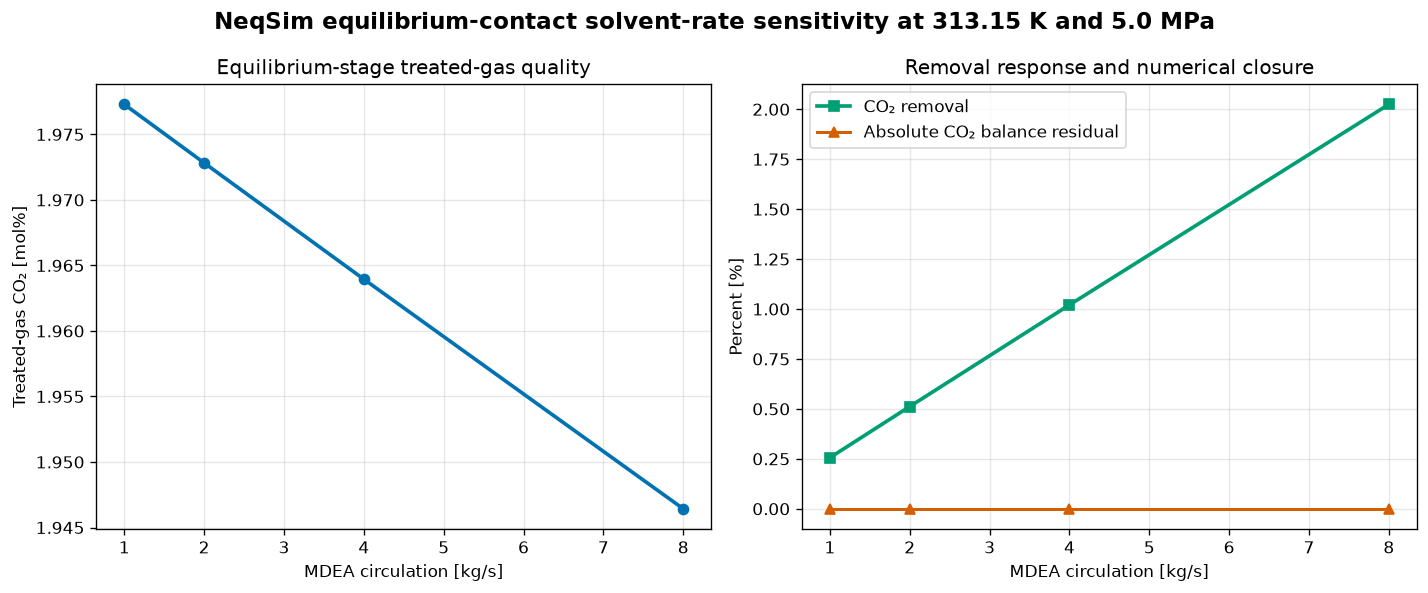

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    contact_results["mdea_mass_rate_kg_per_s"],
    contact_results["treated_gas_co2_mole_percent"],
    marker="o",
    linewidth=2.2,
    color="#0072B2",
)
axes[0].set_xlabel("MDEA circulation [kg/s]")
axes[0].set_ylabel("Treated-gas CO₂ [mol%]")
axes[0].set_title("Equilibrium-stage treated-gas quality")
axes[0].grid(alpha=0.3)

axes[1].plot(
    contact_results["mdea_mass_rate_kg_per_s"],
    contact_results["co2_removal_percent"],
    marker="s",
    linewidth=2.2,
    color="#009E73",
    label="CO₂ removal",
)
axes[1].plot(
    contact_results["mdea_mass_rate_kg_per_s"],
    100.0
    * np.abs(contact_results["co2_balance_residual"]),
    marker="^",
    linewidth=1.8,
    color="#D55E00",
    label="Absolute CO₂ balance residual",
)
axes[1].set_xlabel("MDEA circulation [kg/s]")
axes[1].set_ylabel("Percent [%]")
axes[1].set_title("Removal response and numerical closure")
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.suptitle(
    "NeqSim equilibrium-contact solvent-rate sensitivity at 313.15 K and 5.0 MPa",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()

The practical conclusion is the direction and magnitude of the equilibrium-stage response,
not a universal circulation target. A real MDEA unit must additionally consider lean
loading, absorber temperature rise, column pressure drop, approach to equilibrium, solvent
degradation, corrosion, foaming, hydrocarbon co-absorption, water balance, regenerator
duty, and emissions.

CO₂ removal is calculated from component mass flow:

$$
\eta_{\mathrm{CO_2}} =
1 - \frac{\dot{m}_{\mathrm{CO_2,out}}}
{\dot{m}_{\mathrm{CO_2,in}}}
$$

where $\eta_{\mathrm{CO_2}}$ is dimensionless and each dotted mass rate is in kg/s.

## Independent validation checks

The checks below protect against silent phase-label assumptions, failed reaction
initialization, non-finite equilibrium results, broken model trends, and component or total
mass imbalance. Tolerances are numerical checks for this synthetic case, not accuracy
claims against plant or laboratory data.

In [16]:
checks = {
    "NeqSim version recorded": neqsim_version == "3.16.0",
    "original CPA loading finite": np.isfinite(1.1845921381504203),
    "original CPA bubble pressure positive": (
        original_cpa_bubble_pressure_bara > 0.0
    ),
    "original ScRK bubble pressure positive": (
        original_scrk_bubble_pressure_bara > 0.0
    ),
    "high-pressure flash has gas": speciation_system.hasPhaseType("gas"),
    "high-pressure flash has aqueous": speciation_system.hasPhaseType("aqueous"),
    "aqueous loading finite": np.isfinite(
        calculate_aqueous_loading(speciation_system)
    ),
    "aqueous loading non-negative": (
        calculate_aqueous_loading(speciation_system) >= 0.0
    ),
    "speciation values finite": np.isfinite(
        speciation_table["aqueous_mole_fraction"]
    ).all(),
    "speciation values bounded": (
        speciation_table["aqueous_mole_fraction"].between(0.0, 1.0).all()
    ),
    "CPA grid complete": len(cpa_isotherms) == 8,
    "model grid complete": len(model_comparison) == 8,
    "loading grid finite": np.isfinite(
        cpa_isotherms["loading_mol_per_mol"]
    ).all(),
    "CO2 pressure grid finite": np.isfinite(
        cpa_isotherms["co2_pressure_mpa"]
    ).all(),
    "CO2 pressure grid positive": (
        cpa_isotherms["co2_pressure_mpa"] > 0.0
    ).all(),
    "CPA pressure rises with loading": all(
        (
            group.sort_values("loading_mol_per_mol")["co2_pressure_mpa"]
            .diff()
            .dropna()
            > 0.0
        ).all()
        for _, group in cpa_isotherms.groupby("temperature_k")
    ),
    "warmer CPA curve needs more pressure": all(
        (
            cpa_isotherms[cpa_isotherms["temperature_k"] == 333.15]
            ["co2_pressure_mpa"]
            .to_numpy()
            >
            cpa_isotherms[cpa_isotherms["temperature_k"] == 313.15]
            ["co2_pressure_mpa"]
            .to_numpy()
        )
    ),
    "model comparison in screened pressure range": (
        model_comparison["co2_pressure_mpa"].between(0.0, 10.0)
    ).all(),
    "four process scenarios completed": len(contact_results) == 4,
    "treated gas CO2 finite": np.isfinite(
        contact_results["treated_gas_co2_mole_percent"]
    ).all(),
    "removal bounded": contact_results["co2_removal_percent"].between(
        0.0,
        100.0,
    ).all(),
    "total mass closure": (
        np.abs(contact_results["total_balance_residual"]) < 1.0e-8
    ).all(),
    "CO2 component closure": (
        np.abs(contact_results["co2_balance_residual"]) < 1.0e-8
    ).all(),
    "more solvent lowers treated CO2": (
        contact_results["treated_gas_co2_mole_percent"].diff().dropna() < 0.0
    ).all(),
    "more solvent does not reduce removal": (
        contact_results["co2_removal_percent"].diff().dropna() >= 0.0
    ).all(),
}

failed_checks = [name for name, passed in checks.items() if not bool(passed)]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"

print(f"All {len(checks)} engineering checks passed.")
pd.DataFrame(
    {
        "check": list(checks),
        "passed": [bool(value) for value in checks.values()],
    }
)

All 25 engineering checks passed.


,check,passed
0,NeqSim version recorded,True
1,original CPA loading finite,True
2,original CPA bubble pressure positive,True
3,original ScRK bubble pressure positive,True
4,high-pressure flash has gas,True
5,high-pressure flash has aqueous,True
6,aqueous loading finite,True
7,aqueous loading non-negative,True
8,speciation values finite,True
9,speciation values bounded,True


## Troubleshooting and validity limits

- **No phase named `gas` after `bubp`:** select the infinitesimal phase by its phase
  fraction. At high pressure, Electrolyte-CPA can classify it as liquid-like.
- **Missing ionic species:** call `chemicalReactionInit()` after adding all components and
  before the equilibrium operation.
- **Different or unstable results:** confirm model name, mixing rule, units, component
  rates, NeqSim version, and initialization sequence.
- **A process mixer fails:** construct both inlet fluids with compatible component lists,
  model, mixing rule, reaction initialization, temperature, and pressure.
- **Model comparison is large:** treat this as uncertainty that requires data validation,
  not as permission to average incompatible predictions.
- **Absorber design:** this notebook is equilibrium-stage screening only. Use validated
  rate-based mass transfer, energy balance, hydraulics, degradation, and regenerator models
  for detailed design.

## Summary

- All three original examples are preserved and execute with current NeqSim.
- Reactive electrolyte calculations require explicit reaction initialization and the
  appropriate model-specific mixing rule.
- Total aqueous loading includes molecular and ionic carbon and both neutral and protonated
  MDEA.
- Bubble-point phase labels are not a safe way to identify an infinitesimal second phase.
- NeqSim streams, a mixer, and a separator provide a reusable equilibrium-contact process
  screen with explicit total and CO₂ balances.
- Model and solvent-rate sensitivities are engineering diagnostics, not substitutes for
  project data or rate-based absorber design.

## Further exercises

1. Replace the synthetic sour gas with a documented project composition and repeat the
   solvent-rate screen.
2. Add lean-solvent CO₂ loading and quantify its effect on treated-gas quality.
3. Compare 30, 40, and 50 mass% MDEA while keeping total solvent flow constant.
4. Add an energy balance and estimate the temperature rise from a documented heat of
   absorption.
5. Validate both electrolyte models against a public CO₂–MDEA VLE data set.
6. Extend the one-stage workflow to a sequence of equilibrium contacts and compare it with
   a rate-based column model.

## References

- E. Solbraa, *Equilibrium and non-equilibrium thermodynamics of natural gas processing*,
  NTNU doctoral thesis, 2002. [NTNU Open](
  https://ntnuopen.ntnu.no/ntnu-xmlui/handle/11250/231326)
- [NeqSim project documentation](https://equinor.github.io/neqsim/)
- [NeqSim Python package documentation](
  https://github.com/equinor/neqsim-python)
- A. L. Kohl and R. Nielsen, *Gas Purification*, 5th edition, Gulf Publishing, 1997.

Model results in this notebook are generated by NeqSim 3.16.0 for synthetic inputs. No
experimental accuracy benchmark is claimed.